# BEE 4750 Homework 2: Systems Modeling and Simulation

**Name**: Regina Velasco and Parker Catena

**ID**: rv297 and pdc76

> **Due Date**
>
> Thursday, 09/25/25, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to draw a systems diagram and identify the type
    of a feedback.
-   Problem 2 asks you to model contaminant concentrations in a river
    and use simulation to compare the concentrations to a regulatory
    standard.
-   Problem 3 asks you to explore the implications of an ice-albedo
    feedback in the Earth’s climate system by understanding the
    equilibria of the modeled system and their stabilities.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [21]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/BEE 4750/hw2-regina`


In [22]:
using Plots
using LaTeXStrings
using CSV
using DataFrames
using Roots

## Problems (Total: 30 Points)

### Problem 1 (5 points)

Draw a systems diagram for the relationship between global mean
temperature, atmospheric CO<sub>2</sub> concentrations, and ocean
CO<sub>2</sub> concentrations. What are the signs of the interactions
between these components and why? What does this suggest about the
overall feedback between temperature and the ocean carbon cycle?

In [23]:

"""
                    (+)
Atmospheric CO₂ ─────────►  Global Mean Temperature
 │                              │
 │                              ▼ (-)
 ▲                              |
 │                         Ocean CO₂ 
 │                              │
 └───────────(-)───────────────-┘
"""

"                    (+)\nAtmospheric CO₂ ─────────►  Global Mean Temperature\n │                              │\n │                              ▼ (-)\n ▲                              |\n │                         Ocean CO₂ \n │                              │\n └───────────(-)───────────────-┘\n"

**Problem 1 SOLUTION:**

**Please find a more detailed figure, labeled Figure 1, at the bottom of this PDF. This is incase the figure above is not showing correctly.**

Henry's Law says that solubility of CO₂ in seawater decreases as temperature increases. In other words, warm water holds less CO₂. Because of this, the arrow pointing from global mean temperature to the concentration of CO₂ in the ocean is a negative (-) sign and this is a dampening relationship. As temperature increases, the ocean's water warms and CO₂ concentrations decrease. 

When concentrations of CO₂ in the ocean increase, the concentration of CO₂ in the atmosphere decrease since the ocean is acting as a carbon sink and taking out CO₂ from the atmosphere. Because of this, the sign is negative (-) and this is a dampening relationship.

Finally, when CO₂ concentrations in the atmosphere increases, the greenhouse effect is magnified since the CO₂ is now absorbing heat and re-emitting it. As a result, the global mean temperature to increase. This is an amplifying relationship and the arrow's sign is positive (+). 

This suggests that the overall feedback between temperature and the ocean carbon cycle is an amplyfing (or positive) feedback because an increase in atmospheric CO₂, increases temperature, which creates less CO2 in the ocean, which means less CO₂ is being absorbed by the ocean and there is more of it in the atmosphere, which finally leads to even more warming. 

> **Tip**
>
> Think about Henry’s law for CO<sub>2</sub>.

### Problem 2 (15 points)

A river which flows at 10 km/d is receiving discharges of wastewater
contaminated with CRUD from two sources which are 15 km apart, as shown
in the Figure below. CRUD decays exponentially in the river at a rate of
0.36 $\mathrm{d}^{-1}$ and is deposited by the atmosphere along the
river at a rate of 54 kg/km/d. 

<figure>
<img src="attachment:figures/river_diagram.png"
alt="Schematic of the river system in Problem 2" />
<figcaption aria-hidden="true">Schematic of the river system in Problem
2</figcaption>
</figure>

#### Problem 2.1

Draw a systems diagram with the relevant control volume(s) denoted and
any relevant in/out-flows between these boxes. How did you decide how
many boxes were needed?


**2.1 Solution:**

                Q1, C1                  Q2, C2
                  |                       |
                  |                       |
           -------|--------x=15 km   -----|-----      
          |       ▼       |         |     ▼     |
        Q---->            ----->Q3---->        ----> Q4
          |               |         |           |
          └────────---───--         └───────────


**Above is a rough idea of my systems diagram but please find a more detailed and clear version at the bottom of this PDF labeled as Figure 2.1.**

Two boxes or control volumes are needed for this because there are two input streams, one starting at where the first wastewater input stream mixes into the river up until X = 15 km, right before the second wastewater stream mixes with the river. The second control volume captures the mixing of the second wastewater stream. These streams are causing a change in flow rate of the river so the control volumes will help model and understand those changes. Two equations are needed because the initial conditions are different for each - the river inflow before the first waste stream will have changed due to a few factors such as decay. This will have created a new initial condition of the water mixing with the second waste stream. This will be clearer below.

#### Problem 2.2

Develop a model for the concentration of CRUD downriver by formulating
and solving the appropriate differential equation(s) analytically.

> **Tip**
>
> Formulate your model in terms of distance downriver, rather than
> leaving it in terms of time from discharge.

Concentration at x = 0 km, right after first wastewater input: 1.672 kg/(1000m^3)
Concentration right at x = 15 km, right before second wastewater input: 3.133 kg/(1000m^3)
Concentration right at x = 15 km, right after second wastewater input: 3.796 kg/(1000m^3)
Steady state downstream: 4.286 kg/(1000m^3)


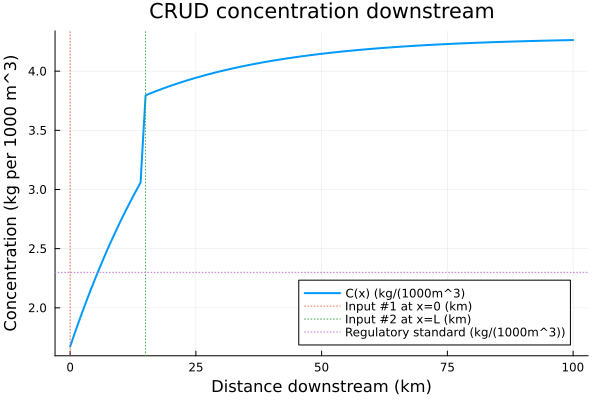

In [24]:

Q = 250000 # river flow rate (m^3/d)
Ci = 0.5/1000 # initial CRUD concentration in river (kg/m^3)
Q1 = 40000 # first wastewater input (kg/day)
C1 = 9/1000 # concentration in first wastewater input (kg/m^3)
Q2 = 60000 # second WW input (kg/m^3)
C2 = 7/1000 # concentration in second WW input (kg/m^3)

k = 0.36 # first order decay rate (1/day)
d = 54 # rate CRUD is deposited by the atmosphere along the river (kg/km/d)
v = 10 # constant average velocity of the river (km/day)
L = 15 # distance between WW input 1 and 2 (km)
A = Q / v


# fcn to find concentration at steady state
function steady_state_C(Q)
    # dC/dx = -decay rate + deposit rate = (-kC/v) + d/Q when dC/dx = 0 because steady state so dC/dX = 0
    k = 0.36 # first order decay rate (1/day)
    d = 54 # rate CRUD is deposited by the atmosphere along the river (kg/km/d)
    v = 10 # constant average velocity of the river (km/day)
    return((v*d)/(k*Q)) 
end

# fcn to find the flow and concentration output of two streams mixing
function two_streams_mix(Q1, C1, Q2, C2)
    Q_out = Q1 + Q2
    C_out = ((Q1*C1) + (Q2*C2)) / Q_out
    return (Q_out, C_out)
end

function conc_model(x, C0, Q)
    k = 0.36 # first order decay rate (1/day)
    d = 54 # rate CRUD is deposited by the atmosphere along the river (kg/km/d)
    v = 10 # constant average velocity of the river (km/day)
    C_out = []
    
    C_out = steady_state_C(Q) .+ (C0 - steady_state_C(Q)) .* exp.((-k/v) .* (x))
    return(C_out)
end


# FIRST MIX: x = 0
(Q3, C3) = two_streams_mix(Q, Ci, Q1, C1)
println("Concentration at x = 0 km, right after first wastewater input: ", round(C3*1000, digits=3), " kg/(1000m^3)")


# conc at x = L- in reach 1
C_L = conc_model(L, C3, Q3)
println("Concentration right at x = 15 km, right before second wastewater input: ", round(C_L*1000, digits=3), " kg/(1000m^3)")

# SECOND MIX: x = 15 km 
(Q4, C4) = two_streams_mix(Q3, C_L, Q2, C2)
println("Concentration right at x = 15 km, right after second wastewater input: ", round(C4*1000, digits=3), " kg/(1000m^3)")


function model(x)
    if x < L #before 15 km
        C_out = steady_state_C(Q3) .+ (C3 - steady_state_C(Q3)) .* exp.((-k/v) .* (x)) 
        C = C_out .*1000

    else #beyond 15 km
        C_out = steady_state_C(Q4) .+ (C4 - steady_state_C(Q4)) .* exp.((-k/v) .* (x-L))
        C = C_out .*1000
    end
    return C
end

c_down_stream = steady_state_C(Q4)*1000
println("Steady state downstream: ", round(c_down_stream, digits=3),  " kg/(1000m^3)")

x = 0:1:100
conc = model.(x)


p = plot(x, conc, lw=2, label="C(x) (kg/(1000m^3)",
         xlabel="Distance downstream (km)",
         ylabel="Concentration (kg per 1000 m^3)",
         title="CRUD concentration downstream")
vline!(p, [0], ls=:dot, label="Input #1 at x=0 (km)")
vline!(p, [L], ls=:dot, label="Input #2 at x=L (km)")
hline!(p, [2.3], ls=:dot, label="Regulatory standard (kg/(1000m^3))")

display(p)


I modeled the river by splitting it into two plug-flows with instantaneous complete mixing at each wastewater input with first-order decay and deposition occurring as well. At each input, I used point-mixing to get the post-mix concentration,
$$
Q_{\text{out}} = Q_a + q_b, \qquad
C_{\text{out}} = \frac{Q_a\,C_a + q_b\,c_b}{Q_{\text{out}}}.
$$
Between inputs (and downstream of the second), concentration changes with distance $x$ thanks to the first-order decay and deposition rate as stated above. The first-order rate is removing CRUD concentration and the deposition rate is adding concentration. I modeled this change in concentration using this equation:

$$
\frac{dC}{dx} = -\frac{k}{v}\,C + \frac{s}{Q}, \qquad
$$
From that equation, I was able to manipulate it to reach the steady state equilibrium equation of 
$$
C_{\mathrm{ss}}(Q) = \frac{v}{k}\,\frac{s}{Q},
$$
and general solution of
$$
C(x) = C_{\mathrm{ss}}(Q) + \bigl(C_{\text{in}} - C_{\mathrm{ss}}(Q)\bigr)\,e^{-(k/v)\,x}.
$$
Using the given flows and concentrations (all in kg/m³), I broke the model down into two equations:
$$
C_1(x) = C_{\mathrm{ss}}(Q_3) + \bigl(C(0^+) - C_{\mathrm{ss}}(Q_3)\bigr)\,e^{-(k/v)\,x},\ for \quad 0 \le x \le L.
$$
and
$$
C_2(x) = C_{\mathrm{ss}}(Q_4) + \bigl(C(L^+) - C_{\mathrm{ss}}(Q_4)\bigr)\,e^{-(k/v)\,(x-L)},\ for \quad x \ge L.
$$
With these equations I got that the following concentration values at a few key distances:

$$C(x\ =\ 0\ km)\ =\ 1.672\ kg/(1000m^3) - right\ after\ first\ wastewater\ input$$

$$C(x\ =\ L^-\ =\ 15\ km)\ =\ 3.133\ kg/(1000m^3)\ -\ just\ before\ second\ wastewater\ input$$

$$C(x\ =\ L^+\ =\ 15\ km)\ =\ 3.796\ kg/(1000m^3)\ -\ immediately\ after\ second\ wastewater\ input$$

$$C{\mathrm{ss}}(Q4)\ =\ 4.286\ kg/(1000m^3)\ -\ further\ downstream\ at\ steady\ state\$$

Finally, I plotted the concentration along the distance of the river in the graph shown above. This provides a visual as to what the concentration is doing overtime using the model and equations I have explained. The concentration of CRUD increases after the first input at $x\ =\ 0$ km and as $x$ gets closer to 15 km the CRUD starts to increase more slowly thanks to the decay rate (despite the deposition rate which is not large enough to overcome the decay). However, after the second input the CRUD concentration increases once again as one would expect. As x gets larger and further from the second input, though, the decay rate again starts to pull the CRUD concentration back down where it will eventually reach a steady state, equilibrium value as long as no other concentration is added.




#### Problem 2.3

Determine if the system in compliance with a regulatory limit of
$2.3\ \text{kg}/(1000 \text{m}^3)$. You can do this analytically or
computationally.

**Response**

By observing the values of $C(0+)$, $C(L-)$, and $C(L+)$, along with the CRUD concentration graph, we can tell the system is not in compliance with the regulatory standard of $2.3\ \text{kg}/(1000 \text{m}^3)$. The stream after waste input $1$ has a concentration of $1.7\ \text{kg}/(1000 \text{m}^3)$, which is within the regulatory standards. However, after traveling downstream roughly $6\ \text{km}$ to $10\ \text{km}$, the waste concentration in the stream continues to increase, causing the concentration to rise above the $2.3\ \text{kg}/(1000 \text{m}^3)$ maximum. One the second source of waste enters the combined stream, the concentration increases to $3.8\ \text{kg}/(1000 \text{m}^3)$, which is well above the regulatory standard of $2.3\ \text{kg}/(1000 \text{m}^3)$.

### Problem 3 (10 points)

In class, we discussed the ice-albedo feedback and its possible
influence on melting the hypothesized [“Snowball
Earth”](https://en.wikipedia.org/wiki/Snowball_Earth). In this problem,
we’ll introduce a simple model of the Earth’s energy balance with
includes this feedback and examine the stability of the climate.

This simple model of the energy balance (averaged over the entire
planet) is:

<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}} + \underbrace{a\ln \left(\frac{[CO_2]}{[CO_2]_{PI}}\right)}_{\text{greenhouse effect}},
 \qquad(1)$$</span>

where:

-   $T$ is the Earth’s global mean temperature (in $^\circ\text{C}$);
-   $C$ is the heat capacity of the atmosphere and shallow ocean, taken
    to be $51\ \text{J}/\text{m}^2/^\circ\text{C}$;
-   $\alpha$ is the planetary albedo, or the fraction of incoming
    radiation reflected by the Earth, which has a present-day value of
    approximately 0.3;
-   $S$ is the solar constant, or the amount of solar radiation received
    by the Earth averaged over area, which has a present-day value of
    $1368\ \text{W}/\text{m}^2$ but during the Neoproteorozoic Era had a
    value of $1272\ \text{W}/\text{m}^2$ (this is divided by four
    because the Earth is a sphere but $S$ is the radiation captured by a
    disc with radius equal to that of the Earth);
-   $A$ and $B$ are coefficients from the linearization of outgoing
    radiation physics, and have corresponding values
    $B=-1.3\ \text{W}/\text{m}^2/^\circ\text{C}$ (estimated from a
    number of lines of evidence about the sensitivity of outgoing
    radiation to temperature; this is negative due to a sign convention
    about the direction of incoming vs. outgoing radiation) and
    $A=221.2\ \text{W}/\text{m}^2$ (estimated by assuming the
    pre-industrial temperature of $14^\circ\text{C}$ was stable without
    anthropogenic greenhouse gas emissions).

We will ignore the greenhouse effect term as we are considering the
Earth system well before humans were around.

#### Problem 3.1

Discretize the climate model
(<a href="#eq-climate" class="quarto-xref">Equation 1</a>) using forward
Euler integration and a time step of $\Delta t = 1$ yr.

Remove the greenhouse term, since it is not relevant in pre-industrial applications:
<span id="eq-climate">$$
\underbrace{C\frac{dT}{dt}}_{\text{change in heat}} = \underbrace{\frac{(1-\alpha)S}{4}}_{\text{incoming radiation}} - \underbrace{(A - BT)}_{\text{outgoing radiation}}
 \qquad$$</span>

Divide by $C$ to isolate $\frac{dT}{dt}$ and distribute the negative:
\begin{equation}
\frac{dT}{dt}
\;=\;
\frac{1}{C}\left(\frac{(1-\alpha)S}{4} - A + B\,T\right)
\end{equation}

Discretize the formula using the forward Euler method of the time derivative at $t$:
\begin{equation}
\frac{T(t+\Delta t)-T(t)}{\Delta t}
\;=\;
\frac{1}{C}\left(\frac{(1-\alpha)S}{4} - A + B\,T(t)\right)
\end{equation}

Multiply by $\Delta t$ and add $T(t)$ to the RHS to simplify the discretized differential equation:
\begin{equation}
T(t+\Delta t)
\;=\;
T(t) + 
\frac{\Delta t}{C}\left(\frac{(1-\alpha)S}{4} - A + B\,T(t)\right)
\end{equation}

#### Problem 3.2

Rather than assuming a constant value for the albedo $\alpha$, we will
represent the ice-albedo feedback by letting $\alpha$ depend on $T$:

$$\alpha(T) = 
    \begin{cases} 
        \alpha_i & \quad \text{if } T \leq -10^\circ \text{C} \\
        \alpha_i + (\alpha_0 - \alpha_i)((T+10) / 20) & \quad \text{if } -10^\circ \text{C} \leq T \leq 10^\circ \text{C} \\
        \alpha_0 & \quad \text{if } T \geq 10^\circ \text{C}.
    \end{cases}$$

Let $\alpha_i = 0.5$ and $\alpha_0 = 0.3$. Simulate the simple climate
model using the Neoprotereozoic value of $S$ with temperature-varying
albedo for initial values of $T$ spanning
$-60^\circ\text{C} \leq T_0 \leq 30^\circ\text{C}$ over a period of 200
years. Plot the temperature trajectories. How many equilibria are there
and what are their stabilities?

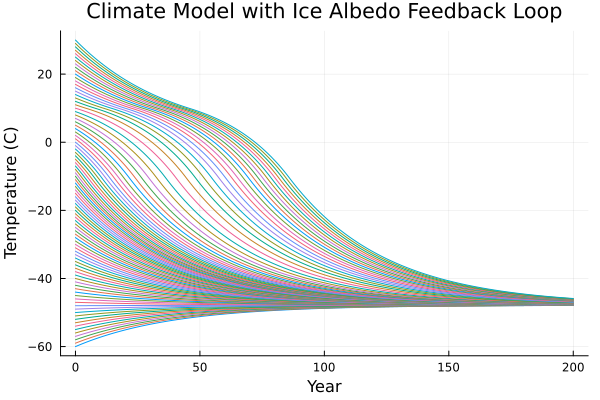

In [25]:
C = 51 # J/m^2/K
S = 1272 # W/m^2
A = 221.2 # W/m^2
B = -1.3 # W/m^2/C
ai = 0.5
ao = 0.3
dt = 1 # time step, yrs
n = 200 # yrs
To = -60:30 # range of initial temperatures, C

#Define an albedo function conditional on temperature
function a(T)
    if T <= -10
        return ai
    elseif T >= 10
        return ao
    else
        return ai + ((ao - ai) * ((T + 10)/20))
    end
end

#Define the simulation function of our discretized differential equation
#including all parameters and calling the albedo function defined above.
function albedo_feedback_sim(C, S, A, B, dt, n, T0)
    T = zeros(n + 1)
    T[1] = T0
    for i in 1:n
        T[i+1] = T[i] + (dt/C) * ((S * (1 - a(T[i])))/4 - A + (B * T[i]))
    end
    return T
end
#Simulate the model for all initial temperatures on [-60, 30]
sims = (T0 -> albedo_feedback_sim(C, S, A, B, dt, n, T0)).(To)
Ts = [t[1:n+1] for t in sims]
yrs = 0:n

#Plot graph of temperature over 200 years for all initial temperature conditions.
plot(yrs, Ts; legend=false, xlabel="Year", ylabel="Temperature (C)", title="Climate Model with Ice Albedo Feedback Loop")

#### Problem 3.3

One might hypothesize that one cause for the transition from Snowball
Earth (the stable frozen equilibrium from Problem 3.2) was an increasing
amount of incoming solar radiation (as expressed by an increase in $S$).
Examine this hypothesis using our simple model. Is this factor enough to
cause the planet to warm to the pre-industrial temperature of
$14^\circ\text{C}$?

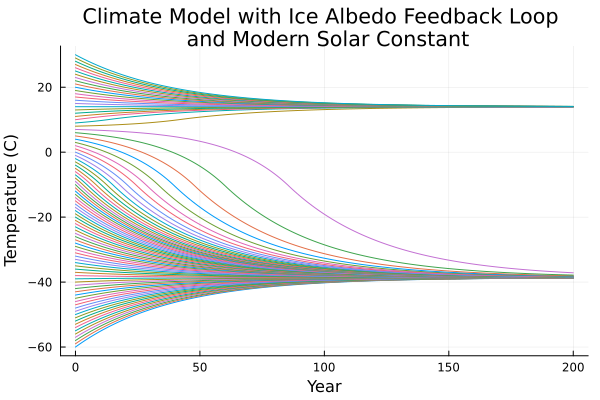

In [26]:
C = 51 # J/m2/K
S = 1368 # W/m2
A = 221.2 # W/m2
B = -1.3 # W/m2/C
ai = 0.5
ao = 0.3
dt = 1 # time step, yrs
n = 200 # yrs
To = -60:30 # range of initial temperatures, C

#Define an albedo function conditional on temperature
function a(T)
    if T <= -10
        return ai
    elseif T >= 10
        return ao
    else
        return ai + ((ao - ai) * ((T + 10)/20))
    end
end

#Define the simulation function of our discretized differential equation
#including all parameters and calling the albedo function defined above.
function albedo_feedback_sim(C, S, A, B, dt, n, T0)
    T = zeros(n + 1)
    T[1] = T0
    for i in 1:n
        T[i+1] = T[i] + (dt/C) * ((S * (1 - a(T[i])))/4 - A + (B * T[i]))
    end
    return T
end
#Simulate the model for all initial temperatures on [-60, 30]
sims = (T0 -> albedo_feedback_sim(C, S, A, B, dt, n, T0)).(To)
Ts = [t[1:n+1] for t in sims]
yrs = 0:n

#Plot graph of temperature over 200 years for all initial temperature conditions.
plot(yrs, Ts; legend=false, xlabel="Year", ylabel="Temperature (C)", title= "Climate Model with Ice Albedo Feedback Loop \n and Modern Solar Constant", titlesize=1)

When looking at the Solar Constant, $S$, in the first model from Question $3.2$, we used the value $S = 1272\ \text{W}/\text{m}^2$ as this was the value of $S$ in the Neoproteorozoic Era. This resulted in a singular equilibrium at a value of $-46^\circ C$. When using the modern Solar Constant of $S$ = $1368\ \text{W}/\text{m}^2$ for the same parameters and albedo function, we see $2$ equilibria: for $8^\circ C\ \text{to}$ $30^\circ C$, $14^\circ C$, and for $7^\circ C\ \text{to}$ $-60^\circ C$, $-46^\circ C$ - the pre-industrial temperature. This indicates that a solar constant of $S = 1368\ \text{W}/\text{m}^{2}$, when combined with our specific assumptions and albeo model, is sufficient to cause warming to $14^\circ C$ for initial temperatures between $8^\circ C$ and $30^\circ C$.

## References

List any external references consulted, including classmates.

